# Extraction of SWR from CA1 recordings

Restarting from LFPwake0 and LFPwakeremoved.

LFPwakeremoved will be used to determined signal variance for threshold adjustement. 

LFPwake0 will be used for time determination. 

## Load LFP and packages

In [1]:
import os
import numpy as np
from pathlib import Path

# ============================================================
# Paths
# ============================================================
base_dir = Path("/Users/stella/Desktop/PhD/paulsen_lab/Analysis/LFP")

# recording (for TTL + timestamps)
rec_folder  = base_dir / "2025-07-30_16-22-55-AM/Record Node 101/experiment1/recording14"
ttl_folder  = rec_folder / "events/Acquisition_Board-102.Rhythm Data/TTL"
cont_folder = rec_folder / "continuous/Acquisition_Board-102.Rhythm Data"

# downsampled LFP
ds_path = base_dir / "downsample/RawDataChannelExtractedDS.npy"
assert ds_path.is_file(), f"Downsampled LFP not found: {ds_path}"

# ============================================================
# Sampling rates
# ============================================================
fs_raw = 2000.0
fs_ds  = 1000.0
ratio  = int(fs_raw / fs_ds)
assert fs_raw % fs_ds == 0, "fs_raw must be integer multiple of fs_ds"

# ============================================================
# Load downsampled LFP
# ============================================================
lfp_ds = np.load(ds_path, mmap_mode="r")   # (time, channels)
n_ds   = lfp_ds.shape[0]

print("Loaded LFP:", lfp_ds.shape, "fs =", fs_ds)

# ============================================================
# Load TTL and convert to DS indices
# ============================================================
stim_samp = np.load(ttl_folder / "sample_numbers.npy")
states    = np.load(ttl_folder / "states.npy")

# anchor: first continuous sample number
cont0 = int(np.load(cont_folder / "sample_numbers.npy", mmap_mode="r")[0])

def extract_ttl1(sample_numbers, states):
    """Return Nx2 array of [start, end] sample numbers (RAW grid)."""
    start_idx = np.where(states == 1)[0]
    end_idx   = np.where(states == -1)[0]
    n = min(len(start_idx), len(end_idx))
    pulses = np.stack(
        [sample_numbers[start_idx[:n]],
         sample_numbers[end_idx[:n]]],
        axis=1
    )
    return pulses[pulses[:, 1] > pulses[:, 0]]

# TTL in raw sample numbers
pulses_raw = extract_ttl1(stim_samp, states)

# convert → raw indices relative to LFP start
pulses_idx = (pulses_raw - cont0).astype(np.int64)

# convert → downsampled indices
pulses_ds = pulses_idx // ratio

# safety clipping
pulses_ds[:, 0] = np.clip(pulses_ds[:, 0], 0, n_ds - 1)
pulses_ds[:, 1] = np.clip(pulses_ds[:, 1], 0, n_ds - 1)
pulses_ds = pulses_ds[pulses_ds[:, 1] > pulses_ds[:, 0]]

print("TTL1 pulses (DS):", pulses_ds.shape)

Loaded LFP: (195968, 32) fs = 1000.0
TTL1 pulses (DS): (651, 2)


In [24]:

def bandpass_150_250(x, fs, order=4):
    """Stable zero-phase bandpass using SOS."""
    x = np.asarray(x, dtype=np.float32)
    nyq = 0.5 * fs
    sos = signal.butter(order, [150/nyq, 250/nyq], btype="bandpass", output="sos")
    return signal.sosfiltfilt(sos, x)

def contiguous_segments(mask):
    """Return list of (start, end) index pairs for True segments in a boolean mask."""
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0:
        return []
    edges = np.diff(mask.astype(np.int8), prepend=0, append=0)
    starts = np.where(edges == 1)[0]
    ends   = np.where(edges == -1)[0]
    return list(zip(starts, ends))

def events_from_mask(mask, fs, min_dur_ms=15, envelope=None):
    """
    Convert threshold mask into events with start/end/peak.
    envelope: optional array for peak finding (defaults to None).
    """
    min_len = int(round(fs * min_dur_ms / 1000.0))
    ev = []
    for s, e in contiguous_segments(mask):
        if (e - s) < min_len:
            continue
        if envelope is None:
            peak = (s + e) // 2
            pkval = np.nan
        else:
            peak = s + int(np.argmax(envelope[s:e]))
            pkval = float(envelope[peak])
        ev.append(dict(start=s, end=e, peak=peak, peak_value=pkval,
                       start_s=s/fs, end_s=e/fs, peak_s=peak/fs,
                       duration_ms=(e - s) * 1000.0 / fs))
    return ev

1️⃣ Define STIM / NO-STIM / PRE-STIM masks (train-based)

In [25]:
import numpy as np
import pandas as pd

def build_stim_mask_from_trains(
    n_samples: int,
    pulses_ds: np.ndarray,
    fs: float,
    gap_s: float = 1.0,          # train boundary if next start - current start > gap_s
    pre_s: float = 0.0,          # optional: expand each train earlier
    post_s: float = 0.0,         # optional: expand each train later
):
    """
    Define STIM-ON as TTL trains:
      - train starts at start of first TTL pulse
      - train ends at end of last TTL pulse before a start-to-start gap > gap_s
    Returns:
      stim_mask (bool, length n_samples)
      trains_ds (Nx2 int): [train_start_idx, train_end_idx] in DS sample indices
      trains_table (pd.DataFrame): train start/end in seconds + duration
    """
    stim_mask = np.zeros(n_samples, dtype=bool)

    if pulses_ds is None or len(pulses_ds) == 0:
        trains_ds = np.zeros((0, 2), dtype=np.int64)
        trains_table = pd.DataFrame(columns=["train_idx", "start_s", "end_s", "duration_s"])
        return stim_mask, trains_ds, trains_table

    pulses = np.asarray(pulses_ds, dtype=np.int64).copy()
    pulses = pulses[pulses[:, 1] > pulses[:, 0]]
    if pulses.size == 0:
        trains_ds = np.zeros((0, 2), dtype=np.int64)
        trains_table = pd.DataFrame(columns=["train_idx", "start_s", "end_s", "duration_s"])
        return stim_mask, trains_ds, trains_table

    # sort by start (safety)
    order = np.argsort(pulses[:, 0])
    pulses = pulses[order]

    starts = pulses[:, 0]
    ends   = pulses[:, 1]

    gap = int(round(gap_s * fs))
    pre = int(round(pre_s * fs))
    post = int(round(post_s * fs))

    trains = []
    cur_start = int(starts[0])
    cur_end   = int(ends[0])

    for i in range(1, len(pulses)):
        # boundary rule based on start-to-start gap
        if (int(starts[i]) - int(starts[i-1])) > gap:
            # close current train
            trains.append((cur_start, cur_end))
            # start new train
            cur_start = int(starts[i])
            cur_end   = int(ends[i])
        else:
            # still same train
            cur_end = max(cur_end, int(ends[i]))

    trains.append((cur_start, cur_end))  # last train

    # Apply optional expansion + build mask
    trains_ds = []
    for s, e in trains:
        s0 = max(0, s - pre)
        e0 = min(n_samples, e + post)
        if e0 > s0:
            stim_mask[s0:e0] = True
            trains_ds.append((s0, e0))

    trains_ds = np.asarray(trains_ds, dtype=np.int64)

    trains_table = pd.DataFrame({
        "train_idx": np.arange(len(trains_ds)),
        "start_s": trains_ds[:, 0] / fs if len(trains_ds) else [],
        "end_s": trains_ds[:, 1] / fs if len(trains_ds) else [],
    })
    if len(trains_table):
        trains_table["duration_s"] = trains_table["end_s"] - trains_table["start_s"]

    return stim_mask, trains_ds, trains_table

# ----------------------------
# Build masks
# ----------------------------
fs = fs_ds
n  = lfp_ds.shape[0]

stim_mask, stim_trains_ds, stim_trains_table = build_stim_mask_from_trains(
    n_samples=n,
    pulses_ds=pulses_ds,
    fs=fs,
    gap_s=1.0,
    pre_s=0.0,
    post_s=0.0
)

nostim_mask = ~stim_mask

# Pre-stim window (10 s before first train)
pre_stim_mask = np.zeros(n, dtype=bool)
pre_stim_window_s = 10.0

if stim_trains_ds is not None and len(stim_trains_ds) > 0:
    first_start = int(stim_trains_ds[0, 0])
    pre_len = int(round(pre_stim_window_s * fs))
    s0 = max(0, first_start - pre_len)
    e0 = max(0, first_start)
    if e0 > s0:
        pre_stim_mask[s0:e0] = True

baseline_mask = nostim_mask  # keep downstream API name
pre_stim_seconds = pre_stim_mask.sum() / fs

display(stim_trains_table)
print("n pulses:", len(pulses_ds))
print("n stim trains:", len(stim_trains_ds))
print("stim samples:", stim_mask.sum(), "(", stim_mask.sum()/fs, "s )")
print("no-stim samples:", nostim_mask.sum(), "(", nostim_mask.sum()/fs, "s )")
print("pre-stim seconds:", pre_stim_seconds)

,train_idx,start_s,end_s,duration_s
0,0,12.579,17.049,4.470
1,1,24.331,26.662,2.331
2,2,36.591,45.315,8.724
3,3,47.767,54.398,6.631
4,4,56.856,64.538,7.682
5,5,69.638,77.295,7.657
6,6,91.506,93.864,2.358
7,7,98.456,100.788,2.332
8,8,102.707,170.116,67.409
9,9,173.659,194.125,20.466


n pulses: 651
n stim trains: 10
stim samples: 130060 ( 130.06 s )
no-stim samples: 65908 ( 65.908 s )
pre-stim seconds: 10.0


Prepare bipolar CA1 signal (important!)

In [31]:
def bipolar(lfp, ch1, ch2):
    return np.asarray(lfp[:, ch1] - lfp[:, ch2], dtype=np.float32)

Method 1 — Jadhav (Hilbert envelope + Gaussian smooth + 3 SD, ≥15 ms)


In [32]:
from scipy import signal
from scipy.ndimage import gaussian_filter1d

def detect_swr_jadhav(
    x, fs, baseline_mask,
    band=(150, 250),
    order=4,
    smooth_ms=4,
    thr_sd=3,
    min_dur_ms=15
):
    # Bandpass
    nyq = 0.5 * fs
    Wn = [band[0]/nyq, band[1]/nyq]
    sos = signal.cheby2(
        N=order,
        rs=20,              # stopband attenuation (dB)
        Wn=Wn,
        btype="bandpass",
        output="sos"
    )
    x_f = signal.sosfiltfilt(sos, x)

    # Envelope
    env = np.abs(signal.hilbert(x_f))

    # Smooth envelope (Gaussian)
    sigma = smooth_ms * fs / 1000
    env_s = gaussian_filter1d(env, sigma=sigma)

    # Baseline stats
    mu = env_s[baseline_mask].mean()
    sd = env_s[baseline_mask].std()
    thr = mu + thr_sd * sd

    # Detect threshold crossings
    above = env_s > thr
    min_len = int(min_dur_ms * fs / 1000)

    events = []
    in_evt = False
    start = 0

    for i, v in enumerate(above):
        if v and not in_evt:
            in_evt = True
            start = i
        elif not v and in_evt:
            if i - start >= min_len:
                events.append((start, i))
            in_evt = False

    return {
        "events": np.array(events),
        "env": env_s,
        "threshold": thr
    }

Method 2 — Kuga (ripple-band RMS in 10 ms bins + 3 SD above baseline, ≥15 ms)


In [33]:
def detect_swr_kuga(
    x, fs, baseline_mask,
    band=(150, 250),
    order=4,
    bin_ms=10,
    thr_sd=3,
    min_dur_ms=15
):
    # Bandpass
    nyq = 0.5 * fs
    Wn = [band[0]/nyq, band[1]/nyq]
    sos = signal.cheby2(
        N=order,
        rs=20,
        Wn=Wn,
        btype="bandpass",
        output="sos"
    )
    x_f = signal.sosfiltfilt(sos, x)

    # RMS envelope
    win = int(bin_ms * fs / 1000)
    rms = np.sqrt(signal.convolve(x_f**2, np.ones(win)/win, mode="same"))

    # Baseline stats
    mu = rms[baseline_mask].mean()
    sd = rms[baseline_mask].std()
    thr = mu + thr_sd * sd

    # Detect events
    above = rms > thr
    min_len = int(min_dur_ms * fs / 1000)

    events = []
    in_evt = False
    start = 0

    for i, v in enumerate(above):
        if v and not in_evt:
            in_evt = True
            start = i
        elif not v and in_evt:
            if i - start >= min_len:
                events.append((start, i))
            in_evt = False

    return {
        "events": np.array(events),
        "rms": rms,
        "threshold": thr
    }

Run both methods on LEFT and RIGHT CA1

In [35]:
fs = fs_ds
n = lfp_ds.shape[0]

# Channel pairs
pairs = {
    "RIGHT": (9, 15),
    "LEFT":  (25, 27)
}

results = {}

for hemi, (c1, c2) in pairs.items():
    x = bipolar(lfp_ds, c1, c2)

    res_j = detect_swr_jadhav(x, fs, baseline_mask)
    res_k = detect_swr_kuga(x, fs, baseline_mask)

    results[hemi] = {
        "Jadhav": res_j,
        "Kuga": res_k
    }

    print(f"{hemi}: Jadhav={len(res_j['events'])}, Kuga={len(res_k['events'])}")

RIGHT: Jadhav=36, Kuga=32
LEFT: Jadhav=26, Kuga=20


In [22]:
# Quick comparison: Jadhav 150–250 vs 100–250 (stim segments only)
import numpy as np

def _event_peaks_from_env(envelope, events):
    peaks = []
    for s, e in np.asarray(events, dtype=int):
        if e <= s:
            continue
        peaks.append(s + int(np.argmax(envelope[s:e])))
    return np.asarray(peaks, dtype=np.int64)

def _match_peaks(peaks_a, peaks_b, tol_samp):
    peaks_a = np.sort(np.asarray(peaks_a, dtype=np.int64))
    peaks_b = np.sort(np.asarray(peaks_b, dtype=np.int64))
    i = j = 0
    matched = 0
    while i < len(peaks_a) and j < len(peaks_b):
        da = peaks_a[i] - peaks_b[j]
        if abs(da) <= tol_samp:
            matched += 1
            i += 1
            j += 1
        elif da < 0:
            i += 1
        else:
            j += 1
    return matched

def _events_in_mask(events, peaks, mask):
    if len(events) == 0:
        return np.empty((0, 2), dtype=int)
    keep = [mask[p] for p in peaks]
    return np.asarray(events)[np.asarray(keep, dtype=bool)]

fs = fs_ds
tol = int(round(20 * fs / 1000))

for hemi, (c1, c2) in pairs.items():
    x = bipolar(lfp_ds, c1, c2)
    r150 = detect_swr_jadhav(x, fs, baseline_mask, band=(150, 250))
    r100 = detect_swr_jadhav(x, fs, baseline_mask, band=(100, 250))

    ev150 = np.asarray(r150["events"]) if len(r150["events"]) else np.empty((0, 2), dtype=int)
    ev100 = np.asarray(r100["events"]) if len(r100["events"]) else np.empty((0, 2), dtype=int)

    p150 = _event_peaks_from_env(r150["env"], ev150)
    p100 = _event_peaks_from_env(r100["env"], ev100)

    ev150_stim = _events_in_mask(ev150, p150, stim_mask)
    ev100_stim = _events_in_mask(ev100, p100, stim_mask)

    p150_stim = _event_peaks_from_env(r150["env"], ev150_stim)
    p100_stim = _event_peaks_from_env(r100["env"], ev100_stim)
    matched_stim = _match_peaks(p150_stim, p100_stim, tol)

    print(f"{hemi}: stim 150–250={len(ev150_stim)} | stim 100–250={len(ev100_stim)} | matched (±20 ms)={matched_stim}")

RIGHT: stim 150–250=20 | stim 100–250=1 | matched (±20 ms)=1
LEFT: stim 150–250=4 | stim 100–250=2 | matched (±20 ms)=0


In [36]:
import numpy as np

def event_peaks_from_envelope(envelope, events):
    """Return peak index (sample) for each event, using envelope maximum inside event."""
    peaks = []
    for s, e in np.asarray(events, dtype=int):
        if e <= s:
            continue
        peaks.append(s + int(np.argmax(envelope[s:e])))
    return np.asarray(peaks, dtype=np.int64)

def match_peaks(peaks_a, peaks_b, tol_samp):
    """Greedy match peaks within tol; returns n_match, unmatched_a, unmatched_b."""
    peaks_a = np.sort(np.asarray(peaks_a, dtype=np.int64))
    peaks_b = np.sort(np.asarray(peaks_b, dtype=np.int64))
    i = j = 0
    matched = 0
    used_b = []
    while i < len(peaks_a) and j < len(peaks_b):
        da = peaks_a[i] - peaks_b[j]
        if abs(da) <= tol_samp:
            matched += 1
            i += 1
            j += 1
        elif da < 0:
            i += 1
        else:
            j += 1
    return matched

def overlap_report(results, hemi, fs, match_ms=20):
    j = results[hemi]["Jadhav"]
    k = results[hemi]["Kuga"]

    # use their own detection signals to define event peaks
    j_peaks = event_peaks_from_envelope(j["env"], j["events"])
    k_peaks = event_peaks_from_envelope(k["rms"], k["events"])

    tol = int(round(match_ms * fs / 1000))
    n_match = match_peaks(j_peaks, k_peaks, tol)

    nJ = len(j["events"])
    nK = len(k["events"])
    prec = n_match / nK if nK else np.nan   # "of Kuga, how many are also in Jadhav"
    rec  = n_match / nJ if nJ else np.nan   # "of Jadhav, how many are also in Kuga"

    print(f"{hemi} overlap (±{match_ms} ms): matched={n_match}")
    print(f"  Jadhav={nJ}, Kuga={nK}")
    print(f"  precision(K→J)={prec:.2f}, recall(J→K)={rec:.2f}")

# Run
fs = fs_ds
overlap_report(results, "RIGHT", fs, match_ms=20)
overlap_report(results, "LEFT",  fs, match_ms=20)

RIGHT overlap (±20 ms): matched=29
  Jadhav=36, Kuga=32
  precision(K→J)=0.91, recall(J→K)=0.81
LEFT overlap (±20 ms): matched=19
  Jadhav=26, Kuga=20
  precision(K→J)=0.95, recall(J→K)=0.73


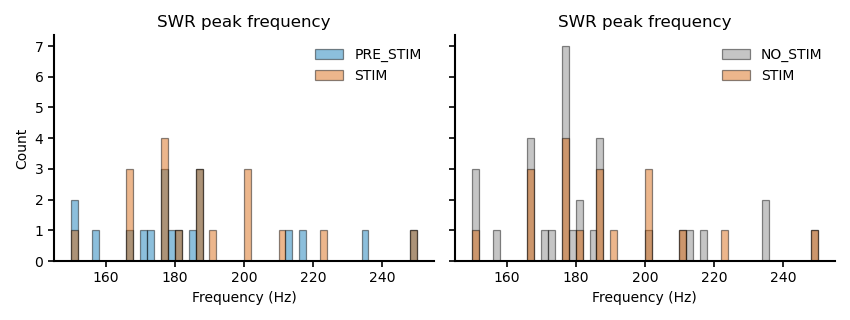

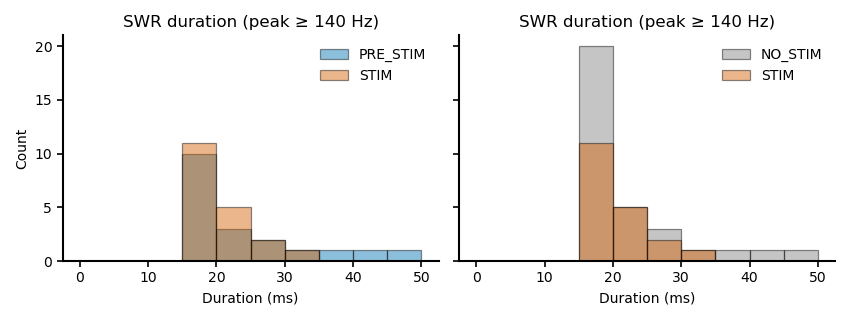

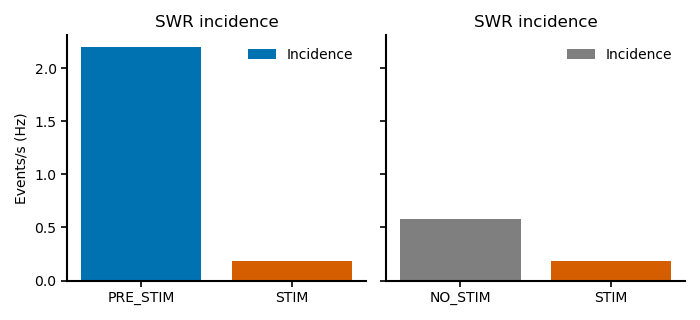

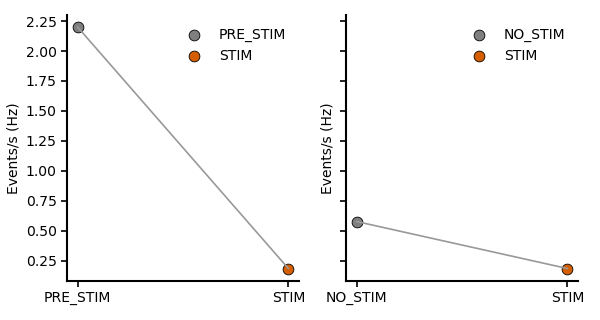

In [40]:
import numpy as np
import matplotlib.pyplot as plt

def event_peak_indices(events, envelope=None):
    peaks = []
    for s, e in np.asarray(events, dtype=int):
        if e <= s:
            continue
        if envelope is None:
            peaks.append((s + e) // 2)
        else:
            peaks.append(s + int(np.argmax(envelope[s:e])))
    return np.asarray(peaks, dtype=np.int64)

def events_by_mask(events, peaks, mask):
    out = []
    for ev, pk in zip(events, peaks):
        if mask[pk]:
            out.append(ev)
    return np.asarray(out, dtype=int)

def spectral_peak_freqs(x, fs, events, band=(150, 250)):
    freqs_out = []
    for s, e in np.asarray(events, dtype=int):
        if e <= s:
            continue
        seg = np.asarray(x[s:e], dtype=np.float32)
        if seg.size < 16:
            continue
        seg = seg - np.mean(seg)
        win = np.hanning(seg.size)
        spec = np.fft.rfft(seg * win)
        pxx = np.abs(spec) ** 2
        freqs = np.fft.rfftfreq(seg.size, d=1 / fs)
        sel = (freqs >= band[0]) & (freqs <= band[1])
        if not np.any(sel):
            continue
        fpk = freqs[sel][np.argmax(pxx[sel])]
        freqs_out.append(float(fpk))
    return np.asarray(freqs_out, dtype=float)

def peak_freqs_per_event(x, fs, events, band=(150, 250)):
    freqs_out = []
    for s, e in np.asarray(events, dtype=int):
        if e <= s:
            freqs_out.append(np.nan)
            continue
        seg = np.asarray(x[s:e], dtype=np.float32)
        if seg.size < 16:
            freqs_out.append(np.nan)
            continue
        seg = seg - np.mean(seg)
        win = np.hanning(seg.size)
        spec = np.fft.rfft(seg * win)
        pxx = np.abs(spec) ** 2
        freqs = np.fft.rfftfreq(seg.size, d=1 / fs)
        sel = (freqs >= band[0]) & (freqs <= band[1])
        if not np.any(sel):
            freqs_out.append(np.nan)
            continue
        fpk = freqs[sel][np.argmax(pxx[sel])]
        freqs_out.append(float(fpk))
    return np.asarray(freqs_out, dtype=float)

def incidence_rate_hz(n_events, mask, fs):
    dur_s = mask.sum() / fs
    return (n_events / dur_s) if dur_s > 0 else np.nan

def style_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)
    ax.tick_params(width=1.2, length=4)

# ----------------------------
# Compute SWR peak frequencies per condition
# ----------------------------
method = "Jadhav"  # or "Kuga"
band_peak = (150, 250)

peakfreq_stim = []
peakfreq_prestim = []
peakfreq_nostim = []

n_stim = 0
n_prestim = 0
n_nostim = 0

ev_stim_all = []
ev_prestim_all = []
ev_nostim_all = []
x_by_hemi = {}

for hemi, (c1, c2) in pairs.items():
    x = bipolar(lfp_ds, c1, c2)
    x_by_hemi[hemi] = x
    res = results[hemi][method]
    env = res.get("env", res.get("rms", None))
    events = np.asarray(res["events"]) if len(res["events"]) else np.empty((0, 2), dtype=int)

    peaks = event_peak_indices(events, envelope=env)

    ev_stim = events_by_mask(events, peaks, stim_mask)
    ev_prestim = events_by_mask(events, peaks, pre_stim_mask)
    ev_nostim = events_by_mask(events, peaks, nostim_mask)

    peakfreq_stim.extend(spectral_peak_freqs(x, fs_ds, ev_stim, band=band_peak))
    peakfreq_prestim.extend(spectral_peak_freqs(x, fs_ds, ev_prestim, band=band_peak))
    peakfreq_nostim.extend(spectral_peak_freqs(x, fs_ds, ev_nostim, band=band_peak))

    ev_stim_all.append((hemi, ev_stim))
    ev_prestim_all.append((hemi, ev_prestim))
    ev_nostim_all.append((hemi, ev_nostim))

    n_stim += len(ev_stim)
    n_prestim += len(ev_prestim)
    n_nostim += len(ev_nostim)

peakfreq_stim = np.asarray(peakfreq_stim)
peakfreq_prestim = np.asarray(peakfreq_prestim)
peakfreq_nostim = np.asarray(peakfreq_nostim)

# ----------------------------
# Histogram: spectral peak frequency (no gaps between bars)
# ----------------------------
bins = np.arange(band_peak[0], band_peak[1] + 2, 2)
bin_w = bins[1] - bins[0]

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.2), sharey=True)

c_pre, _ = np.histogram(peakfreq_prestim, bins=bins)
c_st, _ = np.histogram(peakfreq_stim, bins=bins)
axes[0].bar(bins[:-1], c_pre, width=bin_w, align="edge", alpha=0.45, color="#0072B2", edgecolor="black", linewidth=0.9, label="PRE_STIM")
axes[0].bar(bins[:-1], c_st, width=bin_w, align="edge", alpha=0.45, color="#D55E00", edgecolor="black", linewidth=0.9, label="STIM")
axes[0].set_title("SWR peak frequency")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Count")
axes[0].legend(frameon=False)
style_axes(axes[0])

c_no, _ = np.histogram(peakfreq_nostim, bins=bins)
c_st2, _ = np.histogram(peakfreq_stim, bins=bins)
axes[1].bar(bins[:-1], c_no, width=bin_w, align="edge", alpha=0.45, color="#7f7f7f", edgecolor="black", linewidth=0.9, label="NO_STIM")
axes[1].bar(bins[:-1], c_st2, width=bin_w, align="edge", alpha=0.45, color="#D55E00", edgecolor="black", linewidth=0.9, label="STIM")
axes[1].set_title("SWR peak frequency")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].legend(frameon=False)
style_axes(axes[1])

plt.tight_layout()
plt.show()

# ----------------------------
# Histogram: SWR duration (peak frequency ≥ 140 Hz)
# ----------------------------
def durations_with_peak_ge(events_list, x_lookup, fs, band=(150, 250), min_peak_hz=140):
    out = []
    for hemi, events in events_list:
        if len(events) == 0:
            continue
        x = x_lookup[hemi]
        peak_f = peak_freqs_per_event(x, fs, events, band=band)
        events = np.asarray(events, dtype=int)
        durs_ms = (events[:, 1] - events[:, 0]) * 1000.0 / fs
        keep = (peak_f >= min_peak_hz) & np.isfinite(peak_f)
        out.extend(durs_ms[keep].astype(float))
    return np.asarray(out, dtype=float)

dur_stim = durations_with_peak_ge(ev_stim_all, x_by_hemi, fs_ds, band=band_peak, min_peak_hz=140)
dur_prestim = durations_with_peak_ge(ev_prestim_all, x_by_hemi, fs_ds, band=band_peak, min_peak_hz=140)
dur_nostim = durations_with_peak_ge(ev_nostim_all, x_by_hemi, fs_ds, band=band_peak, min_peak_hz=140)

if len(dur_stim) or len(dur_prestim) or len(dur_nostim):
    max_dur = np.nanmax([np.nanmax(dur_stim) if len(dur_stim) else 0, np.nanmax(dur_prestim) if len(dur_prestim) else 0, np.nanmax(dur_nostim) if len(dur_nostim) else 0])
    bins_dur = np.arange(0, max(20, max_dur + 5), 5)
else:
    bins_dur = np.arange(0, 50, 5)

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.2), sharey=True)

c_pre_d, _ = np.histogram(dur_prestim, bins=bins_dur)
c_st_d, _ = np.histogram(dur_stim, bins=bins_dur)
axes[0].bar(bins_dur[:-1], c_pre_d, width=np.diff(bins_dur), align="edge", alpha=0.45, color="#0072B2", edgecolor="black", linewidth=0.9, label="PRE_STIM")
axes[0].bar(bins_dur[:-1], c_st_d, width=np.diff(bins_dur), align="edge", alpha=0.45, color="#D55E00", edgecolor="black", linewidth=0.9, label="STIM")
axes[0].set_title("SWR duration (peak ≥ 140 Hz)")
axes[0].set_xlabel("Duration (ms)")
axes[0].set_ylabel("Count")
axes[0].legend(frameon=False)
style_axes(axes[0])

c_no_d, _ = np.histogram(dur_nostim, bins=bins_dur)
c_st2_d, _ = np.histogram(dur_stim, bins=bins_dur)
axes[1].bar(bins_dur[:-1], c_no_d, width=np.diff(bins_dur), align="edge", alpha=0.45, color="#7f7f7f", edgecolor="black", linewidth=0.9, label="NO_STIM")
axes[1].bar(bins_dur[:-1], c_st2_d, width=np.diff(bins_dur), align="edge", alpha=0.45, color="#D55E00", edgecolor="black", linewidth=0.9, label="STIM")
axes[1].set_title("SWR duration (peak ≥ 140 Hz)")
axes[1].set_xlabel("Duration (ms)")
axes[1].legend(frameon=False)
style_axes(axes[1])

plt.tight_layout()
plt.show()

# ----------------------------
# Incidence (events/s = Hz)
# ----------------------------
rate_stim = incidence_rate_hz(n_stim, stim_mask, fs_ds)
rate_prestim = incidence_rate_hz(n_prestim, pre_stim_mask, fs_ds)
rate_nostim = incidence_rate_hz(n_nostim, nostim_mask, fs_ds)

fig, axes = plt.subplots(1, 2, figsize=(7, 3.2), sharey=True)

axes[0].bar(["PRE_STIM", "STIM"], [rate_prestim, rate_stim], color=["#0072B2", "#D55E00"], label="Incidence")
axes[0].set_title("SWR incidence")
axes[0].set_ylabel("Events/s (Hz)")
axes[0].legend(frameon=False)
style_axes(axes[0])

axes[1].bar(["NO_STIM", "STIM"], [rate_nostim, rate_stim], color=["#7f7f7f", "#D55E00"], label="Incidence")
axes[1].set_title("SWR incidence")
axes[1].legend(frameon=False)
style_axes(axes[1])

plt.tight_layout()
plt.show()

# ----------------------------
# Paired-dot plots: incidence (Hz)
# ----------------------------
def paired_dot(ax, off_val, on_val, off_label, on_label):
    x0, x1 = 0, 1
    ax.plot([x0, x1], [off_val, on_val], color="0.6", lw=1.2)
    ax.scatter([x0], [off_val], s=60, color="#7f7f7f", edgecolor="black", lw=0.6, label=off_label)
    ax.scatter([x1], [on_val], s=60, color="#D55E00", edgecolor="black", lw=0.6, label=on_label)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([off_label, on_label])
    ax.set_ylabel("Events/s (Hz)")
    ax.legend(frameon=False)
    style_axes(ax)

fig, axes = plt.subplots(1, 2, figsize=(6, 3.2), sharey=True)
paired_dot(axes[0], rate_prestim, rate_stim, "PRE_STIM", "STIM")
paired_dot(axes[1], rate_nostim, rate_stim, "NO_STIM", "STIM")
plt.tight_layout()
plt.show()

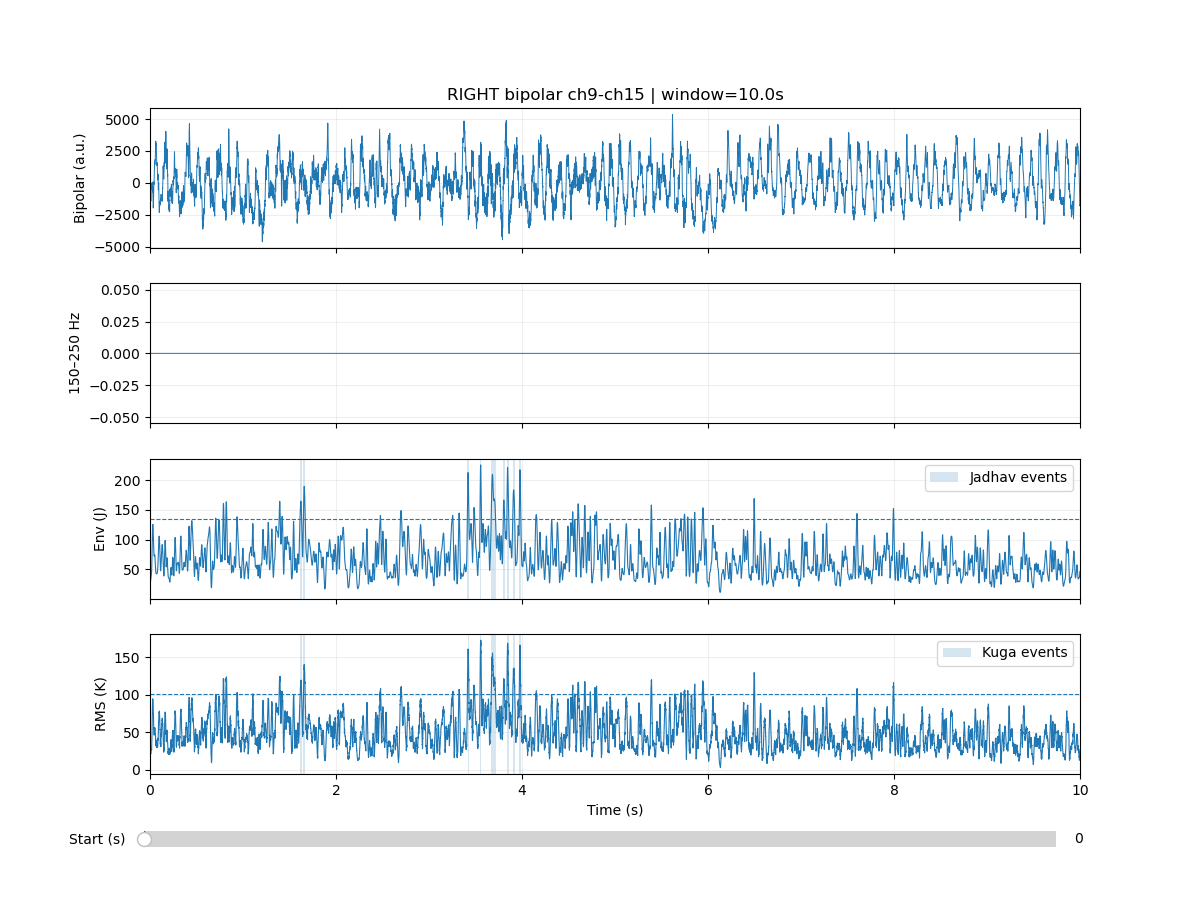

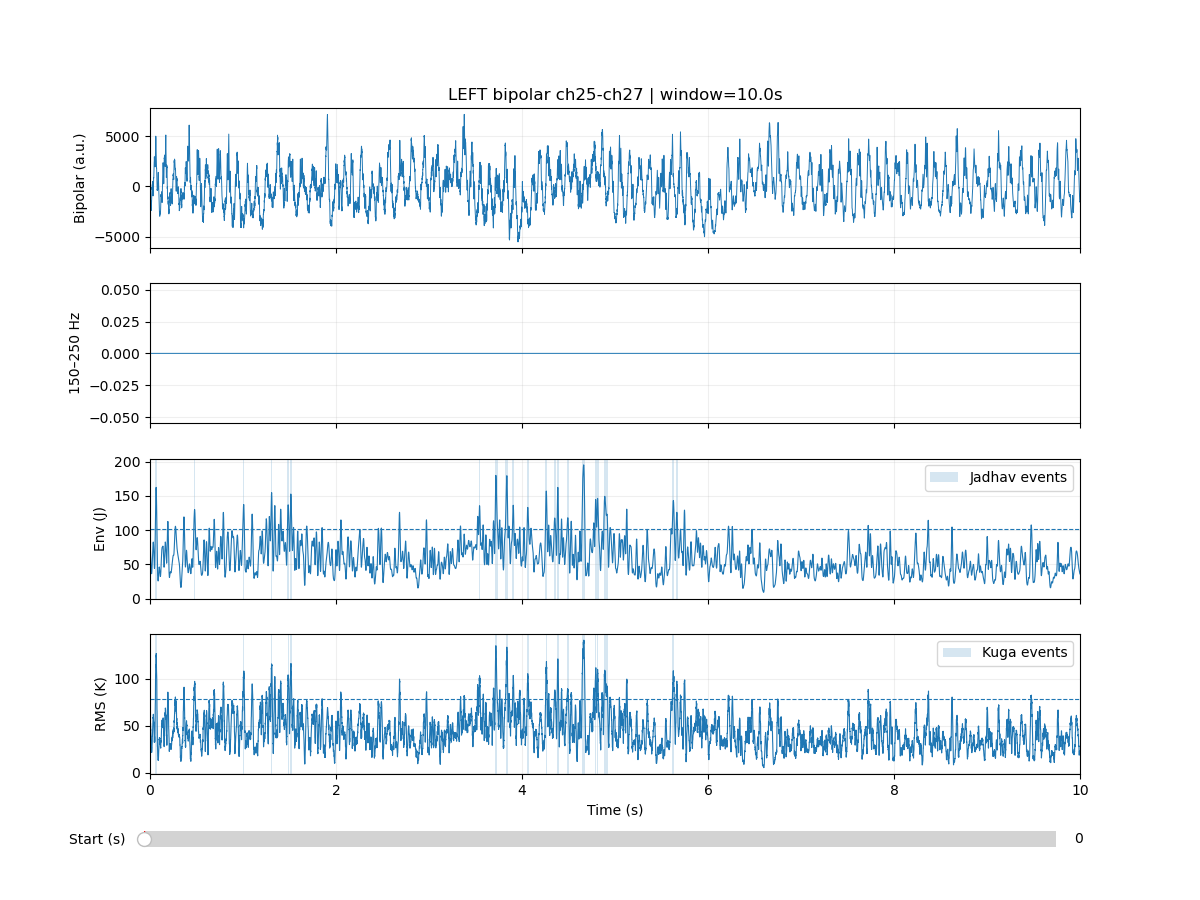

In [12]:
try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    print("Matplotlib widget backend not available. Install ipympl and restart kernel.")

import numpy as np

def events_to_mask(events, n):
    """events: Nx2 array [start,end] sample indices. returns boolean mask length n."""
    m = np.zeros(n, dtype=bool)
    if events is None or len(events) == 0:
        return m
    for s, e in np.asarray(events, dtype=int):
        s = max(0, s); e = min(n, e)
        if e > s:
            m[s:e] = True
    return m

import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import numpy as np

def compare_swr_detections_viewer(
    lfp_ds, fs, pulses_ds,
    pair_right=(9, 15), pair_left=(25, 27),
    results=None,              # output from your detection code (see below)
    hemi="RIGHT",              # "RIGHT" or "LEFT"
    start_s=0.0, window_s=10.0,
    ttl_pad_s=1.0,
    ylim_raw=None, ylim_bp=None
):
    """
    Visual comparison of Jadhav vs Kuga detections.

    results[hemi]["Jadhav"] must contain:
      - "events": Nx2 array
      - "env": array length n
      - "threshold": float

    results[hemi]["Kuga"] must contain:
      - "events": Nx2 array
      - "rms": array length n
      - "threshold": float
      - (optional) "bandpassed": array length n (if not present we compute bp from Jadhav output)
    """

    assert results is not None, "Pass the `results` dict produced by your detection step."
    n = lfp_ds.shape[0]

    # choose pair + bipolar
    if hemi.upper() == "RIGHT":
        ch1, ch2 = pair_right
    else:
        ch1, ch2 = pair_left
    x = np.asarray(lfp_ds[:, ch1] - lfp_ds[:, ch2], dtype=np.float32)

    # grab detection outputs
    j = results[hemi]["Jadhav"]
    k = results[hemi]["Kuga"]

    # ripple bandpassed trace: prefer from Jadhav/Kuga output if you stored it
    x_bp = None
    if "bandpassed" in j:
        x_bp = j["bandpassed"]
    elif "bandpassed" in k:
        x_bp = k["bandpassed"]
    else:
        # if you didn't store it, just plot zeros in the BP panel
        x_bp = np.zeros_like(x)

    env = j["env"]
    thr_j = float(j["threshold"])
    rms = k["rms"]
    thr_k = float(k["threshold"])

    ev_j = np.asarray(j["events"]) if len(j["events"]) else np.empty((0, 2), dtype=int)
    ev_k = np.asarray(k["events"]) if len(k["events"]) else np.empty((0, 2), dtype=int)

    # masks (whole trace) for fast lookup
    mask_j = events_to_mask(ev_j, n)
    mask_k = events_to_mask(ev_k, n)

    # TTL ± pad shading spans (in samples)
    ttl_pad = int(round(ttl_pad_s * fs))
    ttl_spans = []
    for s, e in pulses_ds:
        s0 = max(0, int(s) - ttl_pad)
        e0 = min(n, int(e) + ttl_pad)
        ttl_spans.append((s0, e0))

    # figure
    fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
    plt.subplots_adjust(bottom=0.14, hspace=0.25)

    ax_sl = fig.add_axes([0.12, 0.05, 0.76, 0.035])
    max_start = max(0.0, (n / fs) - window_s)
    sld = Slider(ax_sl, "Start (s)", 0.0, max_start, valinit=start_s)

    def shade_ttl(ax, i0, i1):
        """shade TTL ± pad segments that overlap window"""
        for s0, e0 in ttl_spans:
            if e0 <= i0 or s0 >= i1:
                continue
            ax.axvspan(max(s0, i0) / fs, min(e0, i1) / fs, alpha=0.08)

    def shade_events(ax, i0, i1, events, label, alpha=0.15):
        """shade event spans that overlap window"""
        first = True
        for s, e in events:
            if e <= i0 or s >= i1:
                continue
            ax.axvspan(max(s, i0) / fs, min(e, i1) / fs, alpha=alpha,
                       label=(label if first else None))
            first = False

    def render(s0):
        i0 = int(s0 * fs)
        i1 = min(int((s0 + window_s) * fs), n)
        t = np.arange(i0, i1) / fs

        # clear
        for ax in axes:
            ax.clear()

        # 1) raw bipolar
        axes[0].plot(t, x[i0:i1], lw=0.7)
        shade_ttl(axes[0], i0, i1)
        axes[0].set_ylabel("Bipolar (a.u.)")
        axes[0].set_title(f"{hemi} bipolar ch{ch1}-ch{ch2} | window={window_s}s")
        if ylim_raw is not None:
            axes[0].set_ylim(*ylim_raw)
        axes[0].grid(True, alpha=0.2)

        # 2) ripple-band (150–250)
        axes[1].plot(t, x_bp[i0:i1], lw=0.7)
        shade_ttl(axes[1], i0, i1)
        axes[1].set_ylabel("150–250 Hz")
        if ylim_bp is not None:
            axes[1].set_ylim(*ylim_bp)
        axes[1].grid(True, alpha=0.2)

        # 3) Jadhav envelope + detections
        axes[2].plot(t, env[i0:i1], lw=0.8)
        axes[2].axhline(thr_j, ls="--", lw=0.8)
        shade_events(axes[2], i0, i1, ev_j, "Jadhav events", alpha=0.18)
        shade_ttl(axes[2], i0, i1)
        axes[2].set_ylabel("Env (J)")
        axes[2].grid(True, alpha=0.2)
        axes[2].legend(loc="upper right")

        # 4) Kuga RMS + detections
        axes[3].plot(t, rms[i0:i1], lw=0.8)
        axes[3].axhline(thr_k, ls="--", lw=0.8)
        shade_events(axes[3], i0, i1, ev_k, "Kuga events", alpha=0.18)
        shade_ttl(axes[3], i0, i1)
        axes[3].set_ylabel("RMS (K)")
        axes[3].set_xlabel("Time (s)")
        axes[3].grid(True, alpha=0.2)
        axes[3].legend(loc="upper right")

        axes[3].set_xlim(s0, s0 + window_s)
        fig.canvas.draw_idle()

    sld.on_changed(lambda v: render(sld.val))
    render(start_s)
    plt.show()

# RIGHT hemisphere visual check
compare_swr_detections_viewer(
    lfp_ds, fs_ds, pulses_ds,
    pair_right=(9, 15), pair_left=(25, 27),
    results=results,
    hemi="RIGHT",
    start_s=0.0, window_s=10.0,
    ttl_pad_s=1.0,
    ylim_raw=None,   # or e.g. (-500, 500)
    ylim_bp=None     # or e.g. (-200, 200)
)

# LEFT hemisphere visual check
compare_swr_detections_viewer(
    lfp_ds, fs_ds, pulses_ds,
    pair_right=(9, 15), pair_left=(25, 27),
    results=results,
    hemi="LEFT",
    start_s=0.0, window_s=10.0,
    ttl_pad_s=1.0
)

# Band pass filter
        SWR: 120-200 Hz

## Continuous Wavelet Transform and projection calculation

First on signal with no wake time to determine sd of signal

In [ ]:
# Parameter and computation of CWT
w = 10.
freq = np.linspace(120, 200, 80)
widths = w*fs / (2*freq*np.pi)
CA1NWcwt = signal.cwt(filt_CA1wakeremoved, signal.morlet2, widths, w=w)

# Projection calculation
absCA1NWcwt = np.absolute(CA1NWcwt)
proj_CA1NWcwt = np.sum(absCA1NWcwt, axis = 0)/80
sdproj_CA1cwt = np.std(proj_CA1NWcwt)
sd3proj_CA1cwt = sdproj_CA1cwt*3
sd10proj_CA1cwt = sdproj_CA1cwt*10
sd8proj_CA1cwt = sdproj_CA1cwt*8
sd7proj_CA1cwt = sdproj_CA1cwt*7
sd05proj_CA1cwt = sdproj_CA1cwt*0.5

Second on the signal for which wake times have been zeroed

In [ ]:
# Conservative boolean filtering of CA1 filtered signal
BooleanCons = EMGboolean['BooleanConservative']
fCA1wake0C = filt_CA1.copy()
fCA1wake0C[BooleanCons] = 0
CA1wake0C = CA1.copy()
CA1wake0C[BooleanCons] = 0
# Liberal boolean filtering of CA1 filtered signal
BooleanLib = EMGboolean['BooleanLiberal']
fCA1wake0L = filt_CA1.copy()
fCA1wake0L[BooleanLib] = 0
CA1wake0L = CA1.copy()
CA1wake0L[BooleanLib] = 0

# Computation of CWT
CA1cwtWake0cons = signal.cwt(fCA1wake0C, signal.morlet2, widths, w=w)
CA1cwtWake0lib = signal.cwt(fCA1wake0L, signal.morlet2, widths, w=w)

# Projection calculation
absCA1W0Ccwt = np.absolute(CA1cwtWake0cons)
proj_CA1W0Ccwt = np.sum(absCA1W0Ccwt, axis = 0)/80
absCA1W0Lcwt = np.absolute(CA1cwtWake0lib)
proj_CA1W0Lcwt = np.sum(absCA1W0Lcwt, axis = 0)/80

combined = np.stack([CA1, filt_CA1, proj_CA1W0Ccwt, proj_CA1W0Lcwt], axis = 1)

sample_rate = 1000.
t_start = 0.

## Extracting SWRs and determining main properties 

First extraction of SWR peaks, initiation, end and width

In [ ]:
# 3 sd threshold
peaks, properties = find_peaks(proj_CA1W0Lcwt, prominence=1, width=20, height=sd3proj_CA1cwt)
properties["prominences"], properties["widths"]

# SWR boundaries taken at 70% from peak of intensity. This means that the SWRs with small amplitude will be longer than the big ones.
results_width = peak_widths(proj_CA1W0Lcwt, peaks, rel_height=0.7)

# Organise results in numpy array
peaks2 = peaks.reshape(len(peaks),1)
npresults_width = np.array(results_width).reshape(4,-1)
SWR_prop = np.append(peaks2, results_width).reshape(5,len(peaks2)).round()

Display subset

Second extraction of main frequency and power 

In [ ]:
projMaxP_cwtmg = np.max(CA1cwtWake0lib, axis = 0)
projMaxF_cwtmg = np.argmax(CA1cwtWake0lib, axis = 0) + 120
projMaxP_cwtmg.shape

nb_SWR = len(peaks)
data = np.zeros((nb_SWR,4))

for tt in np.arange(nb_SWR):
    SWR_start = int(SWR_prop[3,tt])
    SWR_stop = int(SWR_prop[4,tt])
    SWR_MaxP = projMaxP_cwtmg[SWR_start:SWR_stop]
    SWR_MaxF = projMaxF_cwtmg[SWR_start:SWR_stop]
    data[tt, 0] = max(SWR_MaxF).round()
    data[tt, 1] = max(SWR_MaxP).round()
    data[tt, 2] = round(sum(SWR_MaxF)/len(SWR_MaxF))
    data[tt, 3] = round(sum(SWR_MaxP)/len(SWR_MaxP))

param_SWR = pd.DataFrame(data, columns = ['Max freq', 'Max int', 'Avg freq', 'Avg int'])
tSWR_prop = SWR_prop.transpose()
pd_prop_SWR = pd.DataFrame(tSWR_prop, columns = ['peak time', 'Duration', 'peak amp', 'start time', 'end time'])
pd_tokeep = pd.DataFrame(np.ones(nb_SWR).astype(bool), columns = ['toKeep'])
All_SWR = pd.concat([pd_tokeep,pd_prop_SWR, param_SWR], axis=1)

SWR_peak = peaks
SWR_start = SWR_prop[3,:].astype(int)
SWR_end = SWR_prop[4,:].astype(int)

### Store the results in All_SWR_prop pd dataframe and save as pkl/csv for post processing.

End of Notebook. 

In [ ]:
filename2 = os.path.join(dpath,f'SWRproperties{suffix}.pkl')
filename3 = os.path.join(dpath,f'SWRproperties{suffix}.csv')
All_SWR.to_pickle(filename2)
All_SWR.to_csv(filename3, sep = ',')

combined = np.stack([CA1, filt_CA1, proj_CA1W0Ccwt, proj_CA1W0Lcwt], axis = 1)
filenameC = os.path.join(dpath,f'SignalCA1.npy')
np.save(filenameC, combined)

sample_rate = 1000.
t_start = 0.
# if done and no intention to display for assessment
#%reset
#plt.close('all')

### Display and asses SWRs

#### ephys viewer to check SWR detection

In [ ]:
%%capture
%gui qt

app = mkQApp()

#Create one data source with 3 event channel
all_events = []
conditions = ['All','Good','Bad']
for c,cond in enumerate(conditions):
    match cond:
        case 'All':
            selection = "All_SWR['toKeep'] | ~All_SWR['toKeep']"
        case 'Good':
            selection = "All_SWR['toKeep']"
        case 'Bad':
            selection = "~All_SWR['toKeep']"
    ev_times = All_SWR.loc[pd.eval(selection),'peak time'].values/1000
    ev_labels = [f'SWR {i}'for i in All_SWR[pd.eval(selection)].index]
    all_events.append({ 'time':ev_times, 'label':ev_labels, 'name': conditions[c] })
source_ev = InMemoryEventSource(all_events=all_events)

combined = np.stack([CA1, fCA1wake0C, proj_CA1W0Lcwt, proj_CA1W0Ccwt, TTL], axis = 1)

sample_rate = 1000.
t_start = 0.

#create 2 familly scatters from theses 2 indexes
scatter_indexes = {0: SWR_peak, 1: SWR_start, 2: SWR_end}
#and asign them to some channels each
scatter_channels = {0: [1, 2], 1: [0, 1], 2: [0, 1]}
source = AnalogSignalSourceWithScatter(combined, sample_rate, t_start, scatter_indexes, scatter_channels)

#Create the main window that can contain several viewers
win = MainViewer(debug=True, show_auto_scale=True)

#create a viewer for signal with TraceViewer
#connected to the signal source
view1 = TraceViewer(source=source)

#Parameters can be set in script
view1.params['scale_mode'] = 'same_for_all'
view1.params['display_labels'] = True
view1.auto_scale()

nCh = len(view1.by_channel_params.children())
mult = 5
for ch in range(nCh):
    match ch%mult:
        case 0: # raw traces
            view1.by_channel_params[f'ch{ch}', 'offset'] = 2.5 + 5*int(ch/mult)
            #view1.by_channel_params[f'ch{ch}', 'gain'] = 0.05
            view1.by_channel_params[f'ch{ch}', 'color'] = '#ffffff'
        case 1: # filtered traces
            view1.by_channel_params[f'ch{ch}', 'offset'] = 0.5 + 5*int(ch/mult)
            #view1.by_channel_params[f'ch{ch}', 'gain'] = 0.1
            view1.by_channel_params[f'ch{ch}', 'color'] = '#0055ff'
        case 2: # envelop
            view1.by_channel_params[f'ch{ch}', 'offset'] = 0.5 + 5*int(ch/mult)
            #view1.by_channel_params[f'ch{ch}', 'gain'] = 0.1
            view1.by_channel_params[f'ch{ch}', 'color'] = '#ff5500'
        case 3: # envelop
            view1.by_channel_params[f'ch{ch}', 'offset'] = 0.5 + 5*int(ch/mult)
            #view1.by_channel_params[f'ch{ch}', 'gain'] = 0.1
            view1.by_channel_params[f'ch{ch}', 'color'] = '#ffffff'
        case 4: # TTL
            view1.by_channel_params[f'ch{ch}', 'offset'] = 4.5 + 5*int(ch/mult)
            #view1.by_channel_params[f'ch{ch}', 'gain'] = 0.1
            view1.by_channel_params[f'ch{ch}', 'color'] = '#ffffff'
view1.params['ylim_max']=5*int((nCh+1)/mult)
view1.params['ylim_min']=0

view2 = EventList(source=source_ev, name='event')


#put this viewer in the main window
win.add_view(view1)
win.add_view(view2, location='bottom',  orientation='horizontal')

#Run
win.show()

#### Select and deselect SWRs

In [ ]:
def clicked(arg):
    selectedEvent = view2.list_widget.currentItem().text()
    selectedSWR = int(selectedEvent.split('SWR')[1])
    #print(selectedSWR)
    match arg.description:
        case 'Keep SWR':
            All_SWR.loc[selectedSWR,'toKeep']=True
            print(f'SWR {selectedSWR} restored')
        case 'Discard SWR':
            All_SWR.loc[selectedSWR,'toKeep']=False
            print(f'SWR {selectedSWR} discarded')
    #save modif
    All_SWR.to_pickle(filename2)
    All_SWR.to_csv(filename3, sep = ',')
    #Create one data source with 3 event channel
    all_events = []
    conditions = ['All','Good','Bad']
    for c,cond in enumerate(conditions):
        match cond:
            case 'All':
                selection = "All_SWR['toKeep'] | ~All_SWR['toKeep']"
            case 'Good':
                selection = "All_SWR['toKeep']"
            case 'Bad':
                selection = "~All_SWR['toKeep']"
        ev_times = All_SWR.loc[pd.eval(selection),'peak time'].values/1000
        ev_labels = [f'SWR {i}'for i in All_SWR[pd.eval(selection)].index]
        all_events.append({ 'time':ev_times, 'label':ev_labels, 'name': conditions[c] })
    source_ev = InMemoryEventSource(all_events=all_events)
    view2.source = source_ev
    view2.refresh_list(view2.combo.currentIndex())

button_Good = widgets.Button(description = 'Keep SWR')   
button_Good.on_click(clicked)

button_Bad = widgets.Button(description = 'Discard SWR')   
button_Bad.on_click(clicked)

display(button_Good, button_Bad)



In [ ]:
# plotting the points
plt.scatter(np.zeros(len(MaxSWR)), MaxSWR)
plt.scatter(np.ones(len(AvgSWR)), AvgSWR)


In [ ]:
# plotting the lines
for i in range(len(MaxSWR)):
    plt.plot( [0,1], [MaxSWR[i], AvgSWR[i]], c='k')
